This notebook constructs a model of a slightly less simple quantum reservoir computer and uses it to predict the evolution of the logistic map.

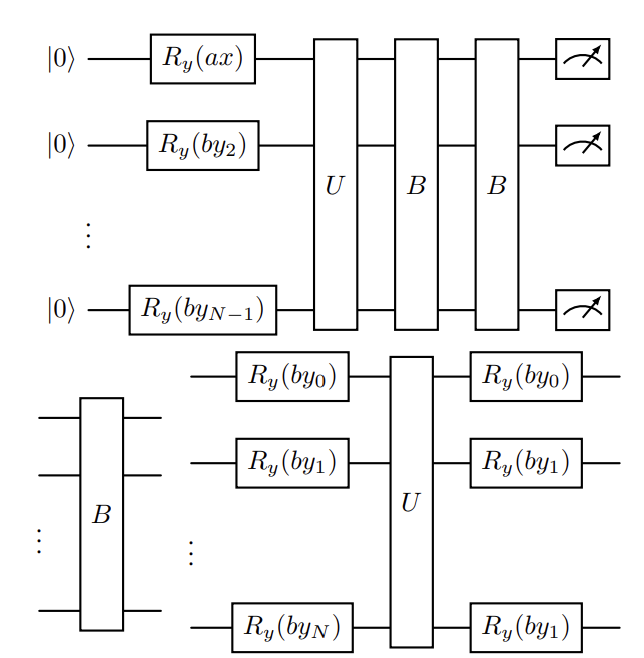

The above circuit is taken from the article https://doi.org/10.48550/arXiv.2505.22837. Here U is a series of C-Not to fully entangle all qubits.

In [158]:
import math
import sys

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm


First we define some useful linear algebra methods, following the construction of a classical ESN from the RC Bootcamp.

In [159]:
class Module(object):
    def __init__(self, *_args, seed=None, rnd=None, dtype=np.float64, **_kwargs):
        if rnd is None:
            self.rnd = np.random.default_rng(seed)
        else:
            self.rnd = rnd
        self.dtype = dtype


class Linear(Module):
    def __init__(self, input_dim: int, output_dim: int, bound: float = None, bias: float = 0.0, **kwargs):
        """
        Linear model

        Args:
            input_dim (int): input dimension
            output_dim (int): output dimension
            bound (float, optional): sampling scale for weight. Defaults to None.
            bias (float, optional): sampling scale for bias. Defaults to 0.0.
        """
        super(Linear, self).__init__(**kwargs)
        self.input_dim = input_dim
        self.output_dim = output_dim
        if bound is None:
            bound = math.sqrt(1 / input_dim)
        self.weight = self.rnd.uniform(-bound, bound, (output_dim, input_dim)).astype(self.dtype)
        self.bias = self.rnd.uniform(-bias, bias, (output_dim,)).astype(self.dtype)

    def __call__(self, x: np.ndarray):
        x = np.asarray(x)
        out = np.matmul(x, self.weight.swapaxes(-1, -2)) + self.bias
        return out


def solution(input_dim, output_dim, seed, bound, bias, mat):
    lin = Linear(input_dim, output_dim, bound=bound, bias=bias, seed=seed)
    return lin(mat)

In [160]:
class LRReadout(Linear):
    def train(self, x: np.ndarray, y: np.ndarray):
        assert (x.ndim == 2) and (x.shape[-1] == self.input_dim)
        assert (y.ndim == 2) and (y.shape[-1] == self.output_dim)
        # Calculate the optimal weight and bias.
        x_biased = np.ones((x.shape[0], x.shape[1] + 1), dtype=self.dtype)
        x_biased[:, 1:] = x
        sol, _residuals, _rank, _s = np.linalg.lstsq(x_biased, y, rcond=None)
        self.weight[:] = sol[1:].T
        self.bias[:] = sol[0]
        return self.weight, self.bias


def solution(dim_in, dim_out, x_train, y_train, x_eval):
    readout = LRReadout(dim_in, dim_out)
    readout.train(x_train, y_train)
    return readout(x_eval)

In [161]:
def calc_nrmse(y, yhat):
    mse = y - yhat
    mse = (mse * mse).mean(axis=0)
    var = y.var(axis=0)
    return (mse / var) ** 0.5


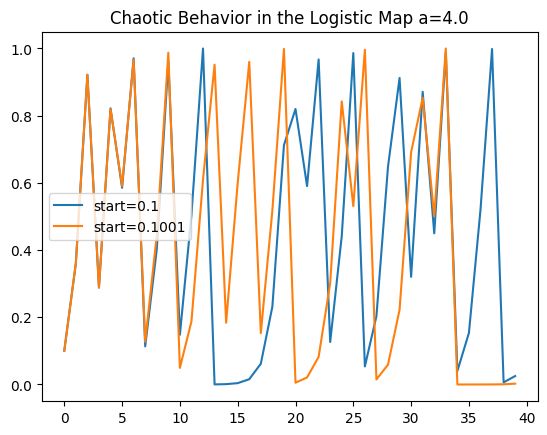

In [162]:
def logistic_func(z, a=4.0):
    z_dot = a * z * (1 - z)
    return z_dot

def generate_logistic_series(start=0.1,a=4.0,length=100):
    series = [start]
    for _ in range(length - 1):
        next_value = logistic_func(series[-1], a)
        series.append(next_value)
    return series

a=4.0
x_series = generate_logistic_series(0.1,a,40)
y_series = generate_logistic_series(0.1001,a,40)


plt.plot(x_series, label="start=0.1")
plt.plot(y_series, label="start=0.1001")
plt.title("Chaotic Behavior in the Logistic Map a="+ str(a))
plt.legend()
plt.show()



We keep track of the coefficient of each qubit state in the wave function in an array of all possible states $(00000,00001,00010,00011 ... , 11111)$

In [163]:
n_bits=5
states=np.zeros(2**n_bits)
states[0]=1   #initialize all qubits at 0

In [164]:
def Ry(states, index, angle):
    k = 2**index                  #representing the qubit as the integer of that qubit being 1
                                  #i^k is the index corresponding to the same state but with the index qubit flipped
    c = np.cos(angle / 2).item()
    s = np.sin(angle / 2).item()

    new_states = states.copy()

    for i in range(len(states)):
        j = i ^ k
        a = states[i]
        b = states[j]

        if j > i:           #this part calculates coefficient of the index qubit being 0
            new_states[i] = c*a - s*b
        else:                #this part calculates coefficient of the index qubit being 1
            new_states[i] = c*a + s*b

    return new_states

#Ry testing, useful to see what Ry actually does
#states_test=np.zeros(16)
#states_test[0]=1
#print(Ry(Ry(states_test,0,1),1,1))


In [165]:
def Big_u(states):
  new_states=states.copy()
  n = int(np.log2(len(states)))

  for i in range(len(states)):
    j=newind(i,n)
    new_states[j]=states[i]
  return new_states

def newind(i,n):      #the index that state b4,b3,b2,b1,b0 (b is 1 or 0) is mapped to is (b4 xor b3 xor ... xor b0, b3 xor ... xor b0, b2 xor b1 xor b0, b1 xor b0, b0)
  j=0
  for a in range(n):  #cool trick for doing these xors
    j=j^((2**a)*i)
  return j%(2**n)

def evaluate(states): #gives the expected value of each qubit being 1, which we measure and feed into the next circuit as the ys
  p_states=states.copy()
  p_states*=states    #probability of each state

  ys=np.zeros(int(np.log2(len(states))))

  for y_ind in range(len(ys)):
    y_pow=2**y_ind

    for p_ind in range(len(p_states)):
      if p_ind^y_pow < y_pow:      #adds if the state at p_ind has qubit at y-ind = 1
        ys[y_ind] += p_states[p_ind]

  return ys




#testing
#print(bin(newind(1,5)))
#states_test=np.zeros(16)
#states_test[0]=1
#print(Ry(Ry(states_test,0,1),1,1))
#print(evaluate(Ry(Ry(states_test,0,1),1,1)))


Now using these circuit components, we build the whole circuit, from start to finish, giving us our output measurement ys from our input of ys and one new input x.

In [166]:
def update_QR(ys,x,a,b):
  num=len(ys)   #gets number of qubits
  states=np.zeros(2**num)
  states[0]=1   #initialize all qubits at 0

  states=Ry(states,0,a*x)   #first set of rotations
  for j in range(1,num):
    states=Ry(states,j,b*ys[j-1])

  states=Big_u(states)      #U

  for j in range(num):      #second set of rotations
    states=Ry(states,j,b*ys[j])
  states=Big_u(states)
  for j in range(num):      #two rotations from the one at the end of B and start of B
    states=Ry(states,j,2*b*ys[j])
  states=Big_u(states)
  for j in range(num):      #last set of rotations
    states=Ry(states,j,b*ys[j])
  exp_values=evaluate(states)
  y_new=np.arccos(exp_values)
  return y_new





Now we train a linear readout to predict the next step in our sequence.

In [79]:
rnd = np.random.default_rng(1234)
t_washout, t_train, t_eval = 10, 200, 100
t_total = t_washout + t_train + t_eval
num_nodes = 5            #change parameters here for experimentation, or mess with the construction of the reservoir update above
a_logistic=3.7
a,b=-0.3,0.1

ts = np.arange(-t_washout, t_train + t_eval)
ser = np.array(generate_logistic_series(0.1,a_logistic,t_total+1)).reshape(-1,1)

w_out = LRReadout(num_nodes, 1)

vs = ser[1:]          #output we want
us = ser[:-1]         #input
xs = us.reshape(-1)


ys=np.linspace(0,1,num_nodes) #start the reservoir at 0
y_record = np.zeros((t_total, num_nodes)) #record of all states for training
for idx in range(t_total):
    ys=update_QR(ys,xs[idx],a,b)
    y_record[idx] = ys


x_train, v_train = y_record[t_washout:-t_eval], vs[t_washout:-t_eval]
x_eval, v_eval = y_record[-t_eval:], vs[-t_eval:]
w_out.train(x_train, v_train)
v_out = w_out(x_eval)
nrmse = calc_nrmse(v_eval, v_out)
print(nrmse)


None

[0.00067471]


Text(0.5, 0, 'time steps')

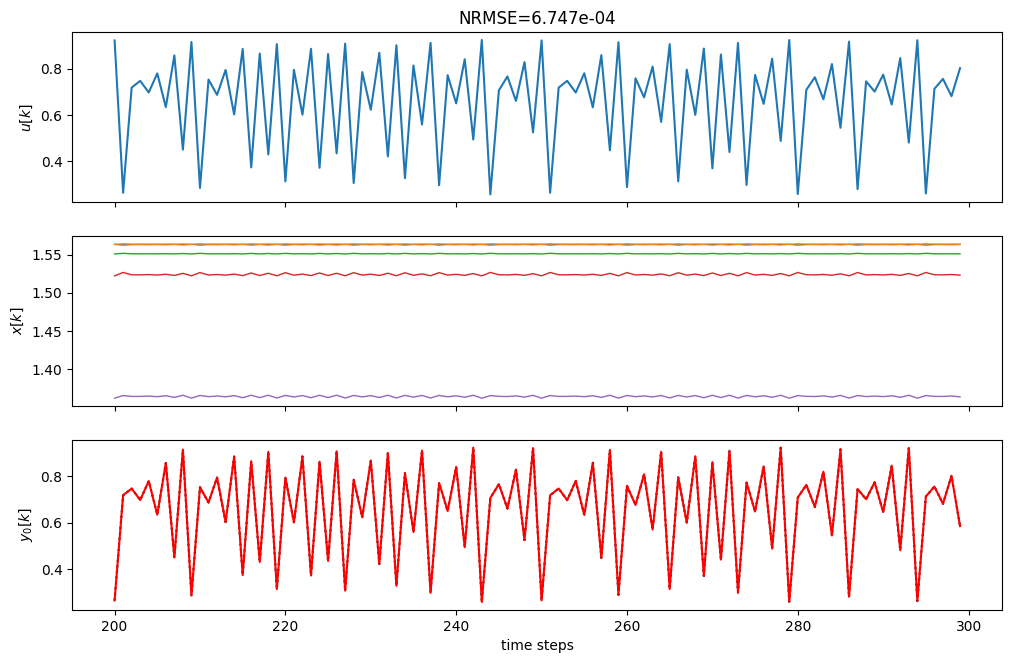

In [80]:
plot_length = min(200,t_eval)
num_extra_series = v_out.shape[1] if v_out.ndim > 1 else 1

# Total subplots:
# 1 for u, 1 for xs (all together), + one per output series
n_plots = 2 + num_extra_series

fig, ax = plt.subplots(n_plots, 1, figsize=(12, 2.5*n_plots),
                       gridspec_kw={"hspace": 0.2})

# --- Input ---
ax[0].plot(ts[-plot_length:], us[-plot_length:])
ax[0].set_ylabel(r"$u[k]$")
ax[0].set_xticklabels([])
ax[0].set_title(f"NRMSE={nrmse[0]:.3e}")

# --- Internal ESN states (ALL on one plot) ---
ax[1].plot(ts[-plot_length:], y_record[-plot_length:], lw=1.0)
ax[1].set_ylabel(r"$x[k]$")
ax[1].set_xticklabels([])

# --- Outputs (separate plots) ---
for i in range(num_extra_series):
    idx = i + 2

    if num_extra_series == 1:
        v_out_i = v_out[-plot_length:]
        v_eval_i = v_eval[-plot_length:]
    else:
        v_out_i = v_out[-plot_length:, i]
        v_eval_i = v_eval[-plot_length:, i]

    ax[idx].plot(ts[-plot_length:], v_eval_i, color="k", ls=":", lw=1.5)
    ax[idx].plot(ts[-plot_length:], v_out_i, color="red", lw=1.5)

    ax[idx].set_ylabel(f"$y_{i}[k]$")
    if i < num_extra_series - 1:
        ax[idx].set_xticklabels([])

ax[-1].set_xlabel("time steps")

Now we feed the output of the trained Quantum Reservoir Computer as the next input. This predicts the sequence for multiple steps  

/tmp/ipykernel_3974/1452503949.py:15: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  new_states[i] = c*a - s*b
/tmp/ipykernel_3974/1452503949.py:17: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  new_states[i] = c*a + s*b


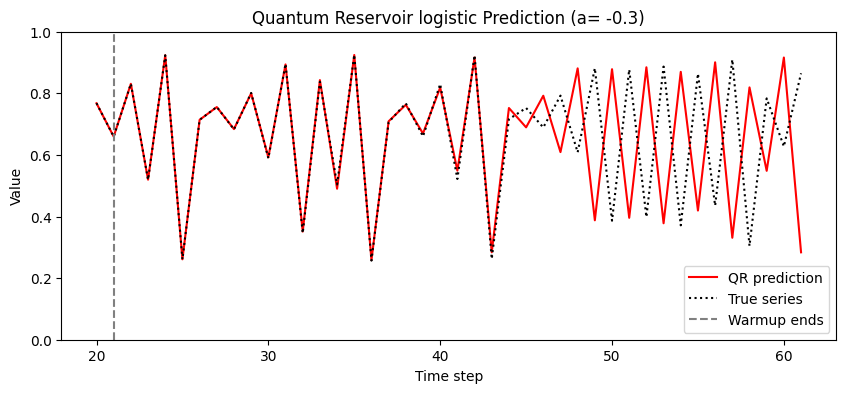

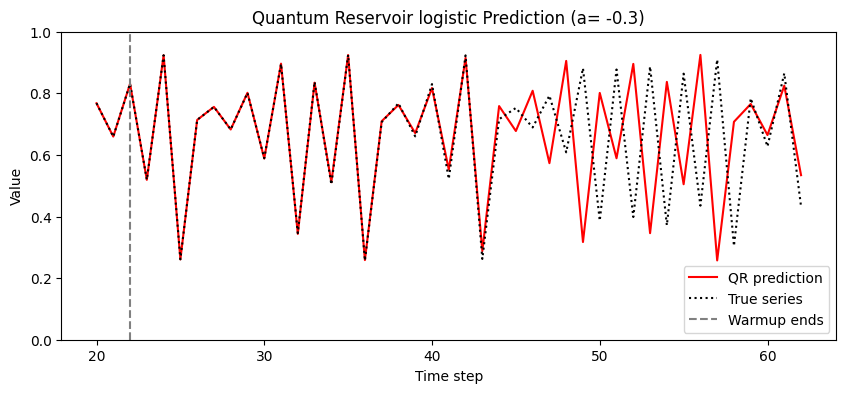

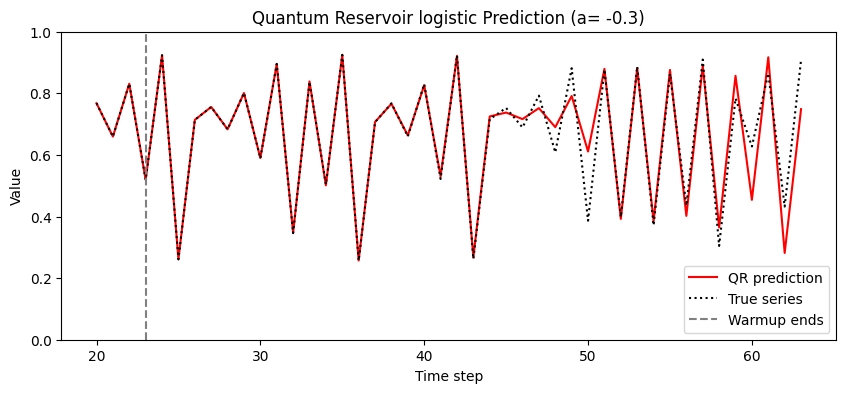

In [83]:
for w_ind in range(3):
  # --- Parameters ---
  warmup_steps = 22+1*w_ind       #simulate random initial conditions by starting prediction at different indices
  pred_steps = 40
  t_total = warmup_steps + pred_steps

  # --- Prepare storage ---
  ys = np.zeros(num_nodes)                # initial reservoir state
  v_gen = np.zeros((t_total, 1))   # generated output
  v_pred=0

  # --- Warmup: feed real inputs to settle reservoir ---
  for idx in range(warmup_steps):
    ys=update_QR(ys,xs[idx],a,b)    # update reservoir
    v_pred = w_out(ys)            # compute output
    v_gen[idx] = v_pred          # store predicted output for warmup

  # --- Closed-loop prediction ---
  for idx in range(warmup_steps, t_total):
      ys=update_QR(ys,v_pred,a,b)        # update reservoir with last output
      v_pred = w_out(ys)            # predict next step
      v_gen[idx] = v_pred          # store prediction

  # --- Plot results starting after 20 steps ---
  plot_start = 20
  plt.figure(figsize=(10,4))
  time_steps = np.arange(plot_start, t_total)

  plt.plot(time_steps, v_gen[plot_start:], 'r', label='QR prediction')
  plt.plot(time_steps, vs[plot_start:t_total], 'k:', label='True series')

  plt.axvline(warmup_steps - 1, color='gray', linestyle='--', label='Warmup ends')

  plt.xlabel('Time step')
  plt.ylabel('Value')
  plt.title('Quantum Reservoir logistic Prediction (a= '+ str(a) + ')')

  plt.ylim(0, 1)  # <-- set y-axis range

  plt.legend()
  plt.show()

Lets make this whole thing a function so it can be called easily.

In [167]:
def qr_log_pred(a_logistic=3.7,num_nodes=5,a_param=-0.3,b_param=0.1,pred_steps=40,num_graphs=3,rnd_seed=1234):
  rnd = np.random.default_rng(rnd_seed)
  t_washout, t_train = 10, 200
  t_eval = pred_steps #guarantee enough data for plots
  t_total = t_washout + t_train + t_eval
  a=a_param
  b=b_param

  ts = np.arange(-t_washout, t_train + t_eval)
  ser = np.array(generate_logistic_series(rnd.random(),a_logistic,t_total+1)).reshape(-1,1)

  w_out = LRReadout(num_nodes, 1)

  vs = ser[1:]          #output we want
  us = ser[:-1]         #input
  xs = us.reshape(-1)


  ys=np.linspace(0,1,num_nodes) #start the reservoir at 0
  y_record = np.zeros((t_total, num_nodes)) #record of all states for training
  for idx in range(t_total):
      ys=update_QR(ys,xs[idx],a,b)
      y_record[idx] = ys


  x_train, v_train = y_record[t_washout:-t_eval], vs[t_washout:-t_eval]
  x_eval, v_eval = y_record[-t_eval:], vs[-t_eval:]
  w_out.train(x_train, v_train)
  v_out = w_out(x_eval)
  nrmse = calc_nrmse(v_eval, v_out).item()

  for w_ind in range(num_graphs):
    # --- Parameters ---
    warmup_steps = rnd.integers(t_washout , t_washout + t_train)       #simulate random initial conditions by starting prediction at different indices
    t_total = warmup_steps + pred_steps

    # --- Prepare storage ---
    ys = np.zeros(num_nodes)                # initial reservoir state
    v_gen = np.zeros((t_total, 1))   # generated output
    v_pred=0

    # --- Warmup: feed real inputs to settle reservoir ---
    for idx in range(warmup_steps):
      ys=update_QR(ys,xs[idx],a,b)    # update reservoir
      v_pred = w_out(ys)            # compute output
      v_gen[idx] = v_pred          # store predicted output for warmup

    # --- Closed-loop prediction ---
    for idx in range(warmup_steps, t_total):
        ys=update_QR(ys,v_pred,a,b)        # update reservoir with last output
        v_pred = w_out(ys)            # predict next step
        v_gen[idx] = v_pred          # store prediction

    # --- Plot results starting after 20 steps ---
    plot_start = warmup_steps-4
    plt.figure(figsize=(10,4))
    time_steps = np.arange(-4, pred_steps)

    plt.plot(time_steps, v_gen[plot_start:], 'r', label='QR prediction')
    plt.plot(time_steps, vs[plot_start:t_total], 'k:', label='True series')

    plt.axvline(0, color='gray', linestyle='--', label='Warmup ends')

    plt.xlabel('Time step')
    plt.ylabel('Value')
    plt.title('Quantum Reservoir logistic Prediction (a= '+ str(a_logistic) + ')')  #want logistic constant a, not hyperparameter a

    plt.ylim(0, 1)  # <-- set y-axis range

    plt.legend()
    plt.show()
  return nrmse #for optimization

Here is the place to experiment, remember the parameters are:
-logistic map constant a
-number of qubits
-input hyperparameter a
-internal hyperparameter b
-number of prediction steps shown on the graph
-number of graphs

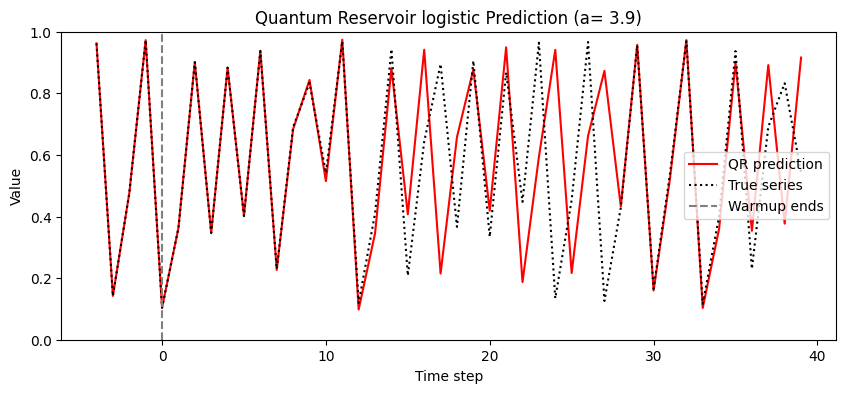

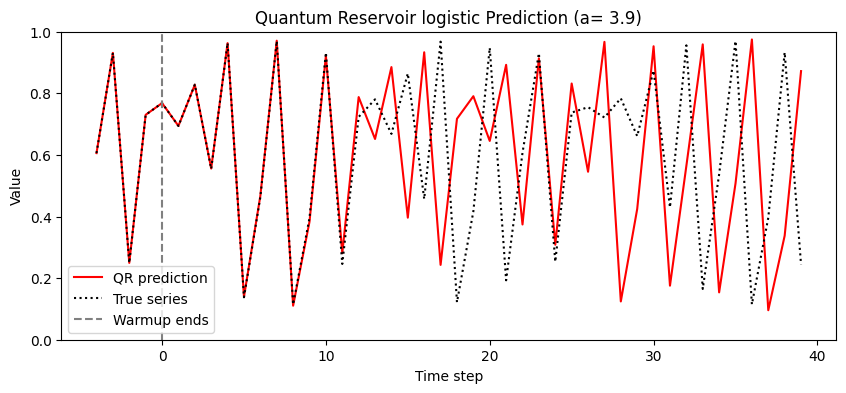

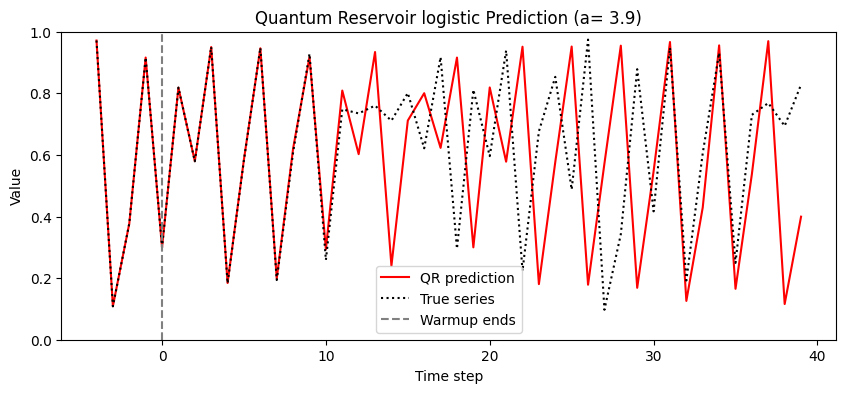

0.00034572742875857107


In [130]:
print(qr_log_pred(3.9,6,-0.3,0.15,40,3,1111))


The continuation of this is to optimize the hyperparameters a and b for any given logistic constant and number of qubits. This is simple but computationally expensive, depending on level of optimization and number of qubits (especially big influence since the number of states is exponential in the number of qubits)

In [168]:
def randomOptimum(a_logistic=3.7,num_nodes=5,attempts=50,rnd_seed=1234):
  rnd = np.random.default_rng(rnd_seed)
  best_nrmse = np.inf
  best_a = None
  best_b = None
  arr=[best_a, best_b, best_nrmse]

  for i in range(attempts):
    a = rnd.uniform(-1.0, 1.0)
    b = rnd.uniform(0.0, 1.0)

    nrmse = qr_log_pred(a_logistic,num_nodes,a,b,40,0,rnd_seed)

    if nrmse < arr[2]:
        arr[2] = nrmse
        arr[0] = a
        arr[1] = b

  return arr



In [145]:
print(randomOptimum(3.8,5,60,1232))
print(randomOptimum(3.8,5,60,1233))
print(randomOptimum(3.8,5,60,1234))

[-0.0013312556958413602, 0.021831655631130764, 0.00042304425852044563]
[0.5094898446920688, 0.02954268952786998, 0.0005015261605095021]
[-0.3185103218873053, 0.053001962545479286, 0.0007003327295537182]


Given this isn't the most reliable method because it generates vastly different a and b every time, lets visualize the nmrse for different a and b.

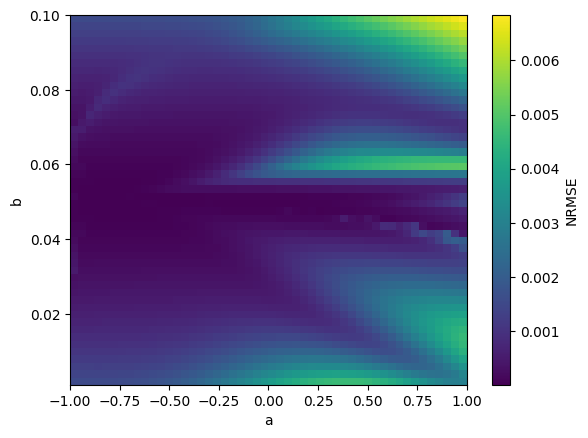

In [148]:
a_logistic=3.8
num_nodes = 5
a_vals = np.linspace(-1, 1, 50)
b_vals = np.linspace(0.001, 0.1, 50)

losses = np.zeros((50, 50))

for i, a in enumerate(a_vals):
    for j, b in enumerate(b_vals):
        losses[i, j] = qr_log_pred(a_logistic, num_nodes, a, b, 40, 0, 1234)
plt.imshow(
    losses,
    origin="lower",
    aspect="auto",
    extent=[a_vals[0], a_vals[-1], b_vals[0], b_vals[-1]]
)

plt.xlabel("a")
plt.ylabel("b")
plt.colorbar(label="NRMSE")

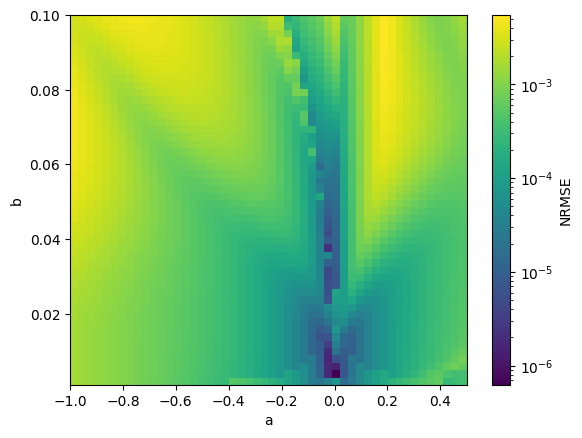

In [151]:
a_logistic=3.8
num_nodes = 5
a_vals = np.linspace(-1, 0.5, 50)
b_vals = np.linspace(0.001, 0.1, 50)

losses = np.zeros((50, 50))

for i, a in enumerate(a_vals):
    for j, b in enumerate(b_vals):
        losses[i, j] = qr_log_pred(a_logistic, num_nodes, a, b, 40, 0, 1234)

plt.imshow(
    losses.T,
    origin="lower",
    aspect="auto",
    extent=[a_vals[0], a_vals[-1], b_vals[0], b_vals[-1]],
    norm=LogNorm()
)

plt.xlabel("a")
plt.ylabel("b")
plt.colorbar(label="NRMSE")

In [169]:
a_logistic=3.8
num_nodes = 5
a_vals = np.linspace(-0.1, 0.05, 50)
b_vals = np.linspace(0.001, 0.07, 50)

losses = np.zeros((50, 50))

for i, a in enumerate(a_vals):
    for j, b in enumerate(b_vals):
        losses[i, j] = qr_log_pred(a_logistic, num_nodes, a, b, 40, 0, 1234)

plt.imshow(
    losses.T,
    origin="lower",
    aspect="auto",
    extent=[a_vals[0], a_vals[-1], b_vals[0], b_vals[-1]],
    norm=LogNorm()
)

plt.xlabel("a")
plt.ylabel("b")
plt.colorbar(label="NRMSE")

KeyboardInterrupt: 

These are some nice visualizations. With this many valleys and lines optimization becomes difficult. Lets just use the best value for now.

[np.float64(-0.005102040816326522), np.float64(0.003816326530612245)]


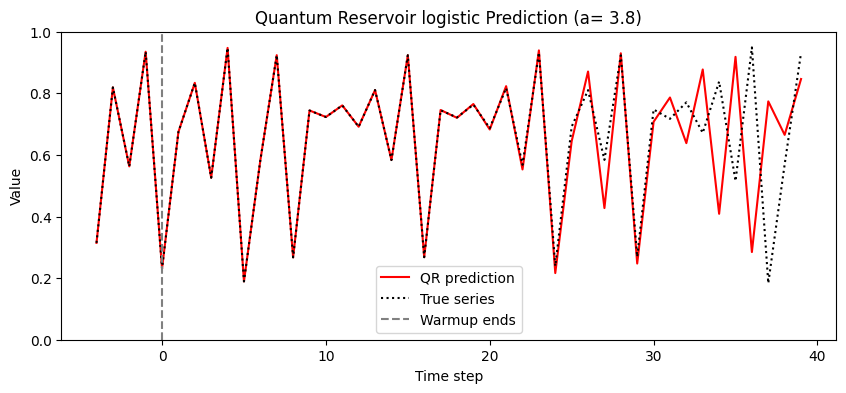

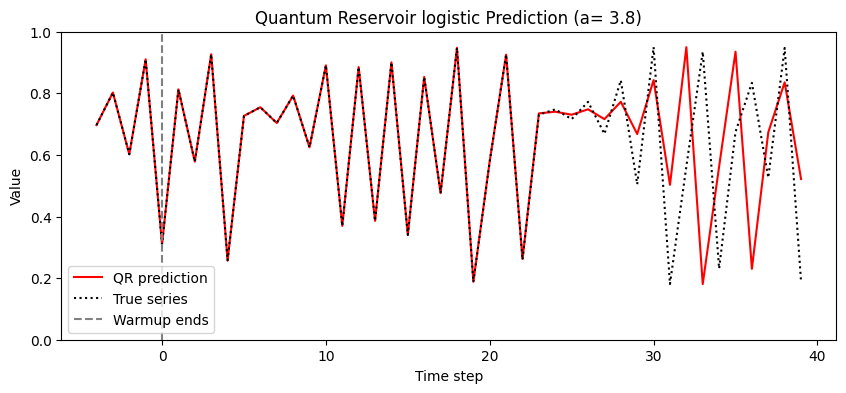

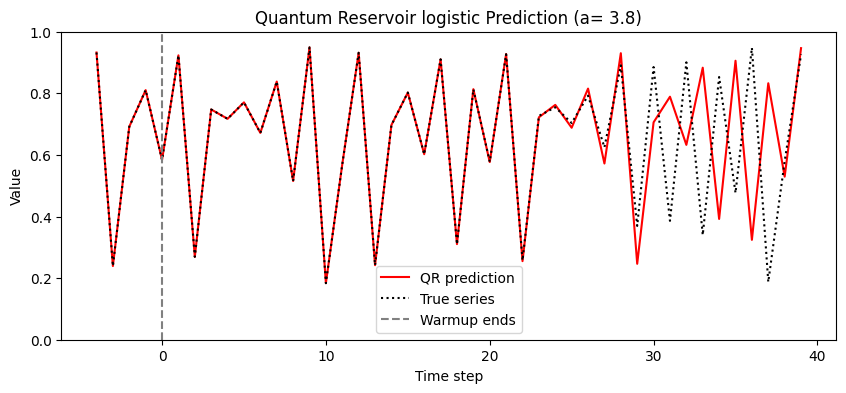

1.8515549186503454e-07

In [155]:
idx = np.unravel_index(np.argmin(losses), losses.shape)
best_a = a_vals[idx[0]]
best_b = b_vals[idx[1]]
best_loss = losses[idx]
print([best_a,best_b])
qr_log_pred(a_logistic, num_nodes, best_a, best_b, 40, 3, 1233)


As a test of reliability lets change the random seed and see if we still get the same contour graph

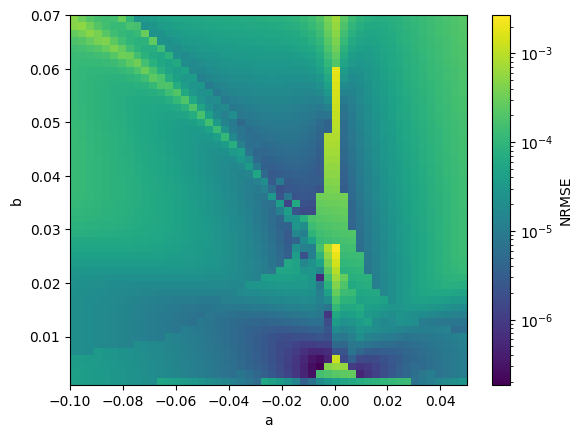

In [170]:
a_vals = np.linspace(-0.1, 0.05, 50)   #making the same contour graph as the last but with different random seed
b_vals = np.linspace(0.001, 0.07, 50)

losses = np.zeros((50, 50))

for i, a in enumerate(a_vals):
    for j, b in enumerate(b_vals):
        losses[i, j] = qr_log_pred(a_logistic, num_nodes, a, b, 40, 0, 1233)

plt.imshow(
    losses.T,
    origin="lower",
    aspect="auto",
    extent=[a_vals[0], a_vals[-1], b_vals[0], b_vals[-1]],
    norm=LogNorm()
)

plt.xlabel("a")
plt.ylabel("b")
plt.colorbar(label="NRMSE")

As we can see, the graph is virtually the same, so the hyperparameters are optimal regardless of randomness. We are actually seeing the structure here, and negligable noise. Lets look closer.

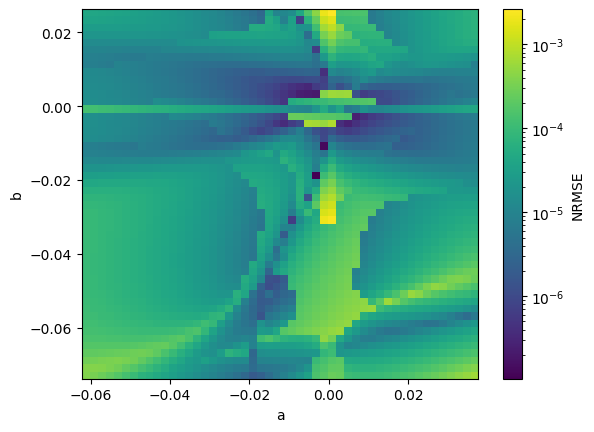

In [173]:
idx = np.unravel_index(np.argmin(losses), losses.shape)
best_a = a_vals[idx[0]]
best_b = b_vals[idx[1]]
best_loss = losses[idx]
a_vals = np.linspace(best_a - 0.05, best_a + 0.05, 50)
b_vals = np.linspace(best_b - 0.05, best_b + 0.05, 50)
losses = np.full((50, 50), np.nan)

for i, a in enumerate(a_vals):
  if a != 0:
    for j, b in enumerate(b_vals):
        losses[i, j] = qr_log_pred(a_logistic, num_nodes, a, b, 40, 0, 1233)

plt.imshow(
    losses.T,
    origin="lower",
    aspect="auto",
    extent=[a_vals[0], a_vals[-1], b_vals[0], b_vals[-1]],
    norm=LogNorm()
)

plt.xlabel("a")
plt.ylabel("b")
plt.colorbar(label="NRMSE")

